In [1]:
%run statisticsSource.ipynb

### Load data

In [2]:
folder = "paper4_test_plus_o"

currentFolder = baseFolder+folder
df = getStatisticsDataframe(currentFolder)

  0%|          | 0/1428 [00:00<?, ?it/s]

### paper4_test_plus_o

Count:
1
1
100


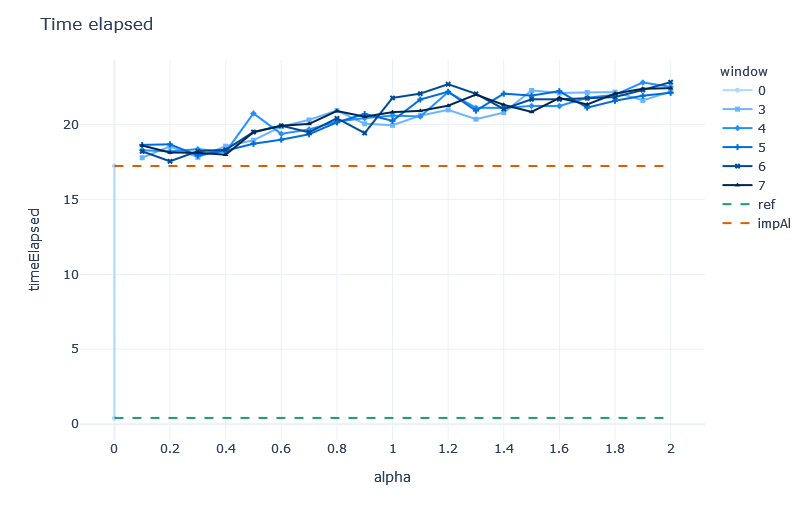

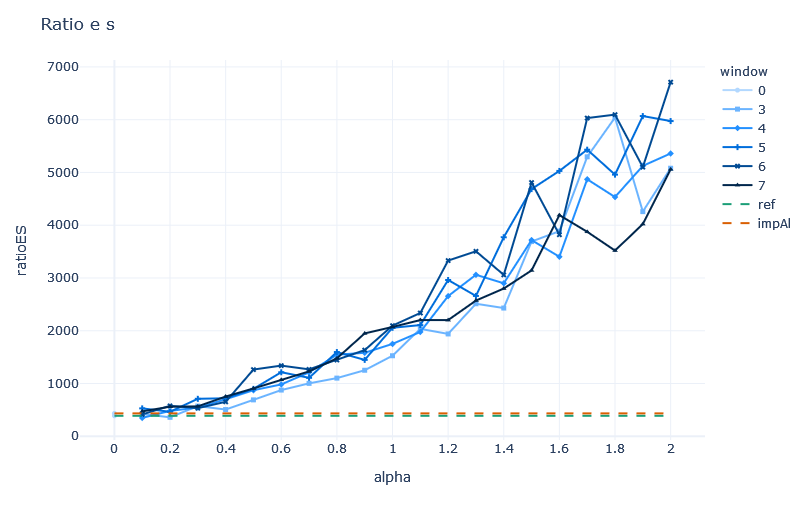

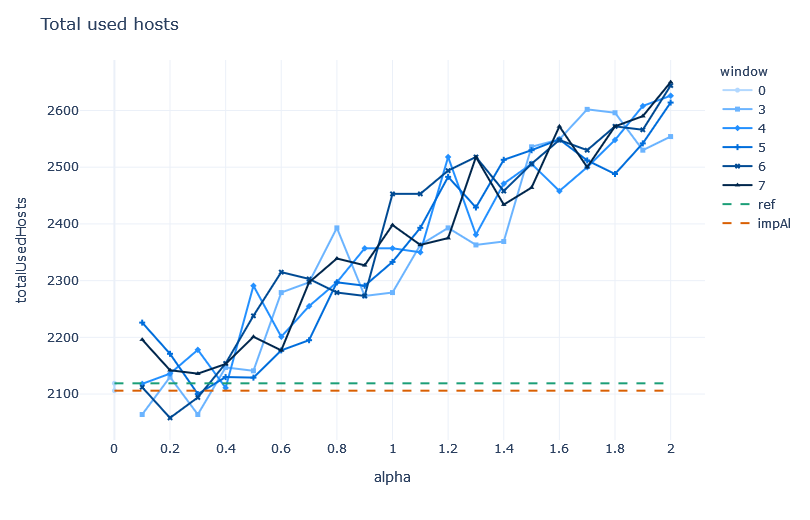

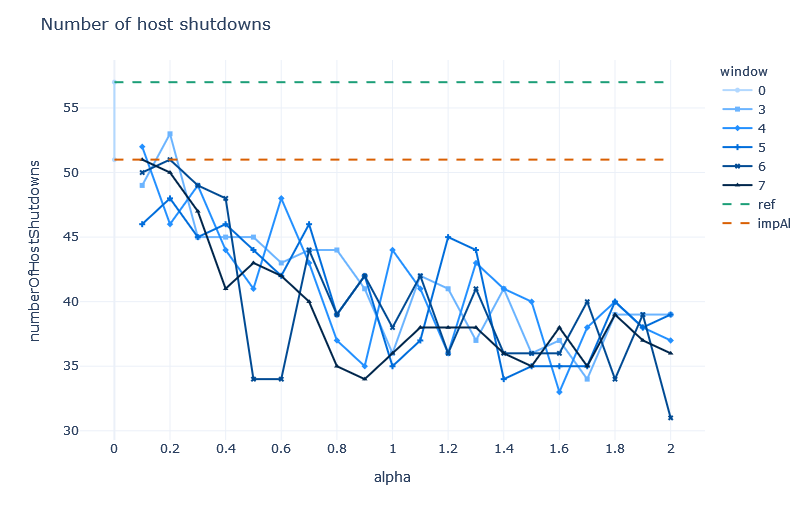

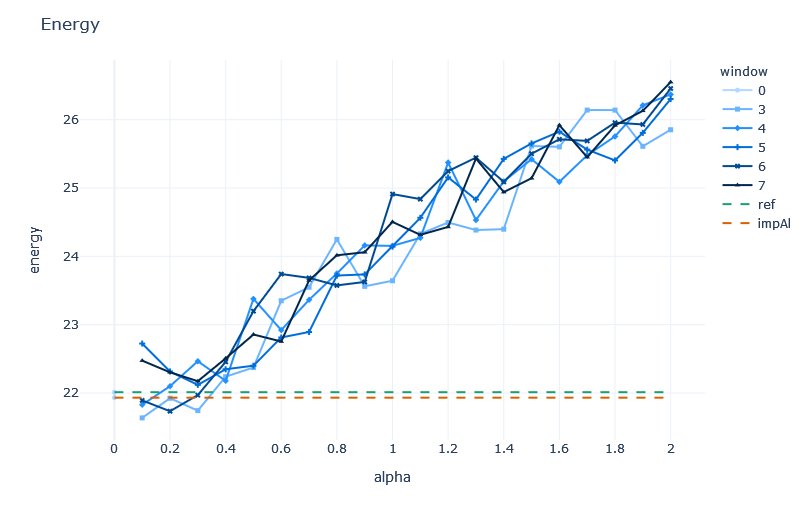

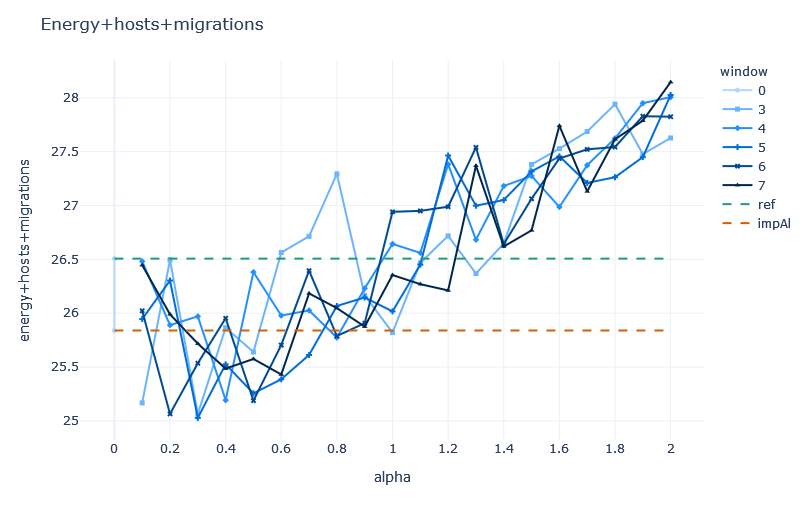

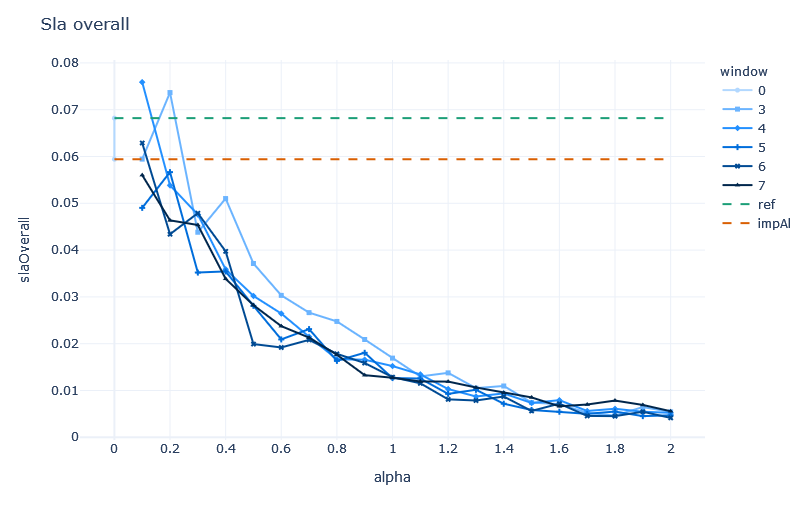

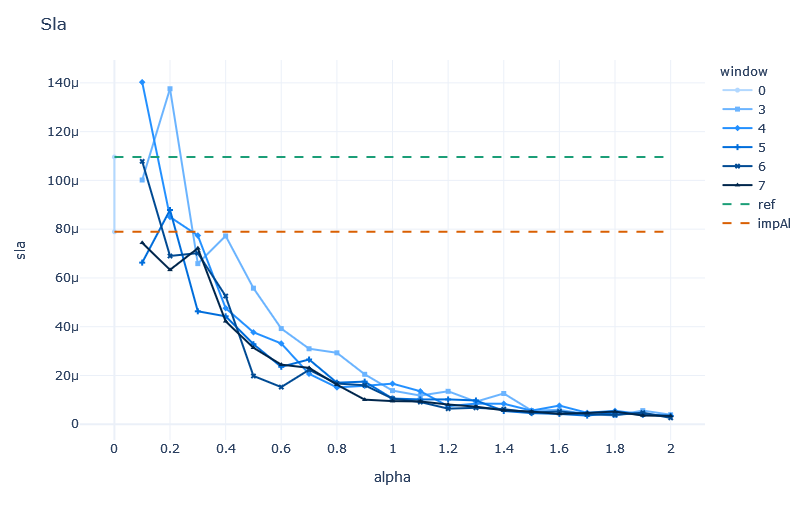

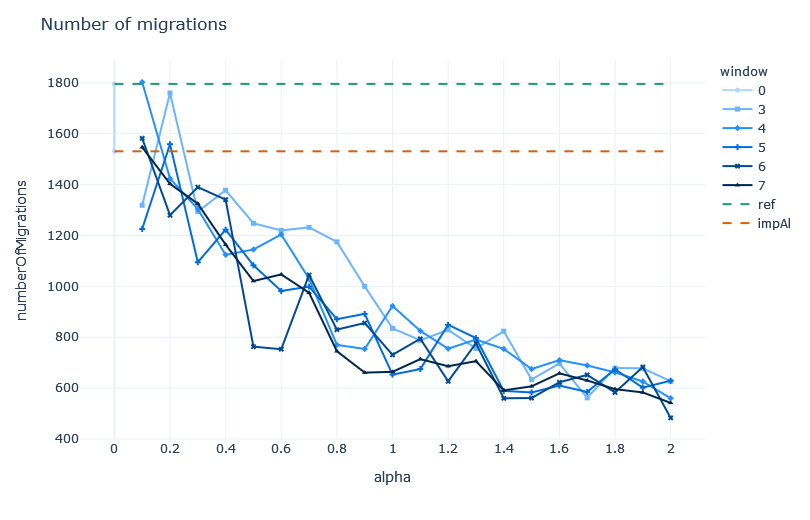

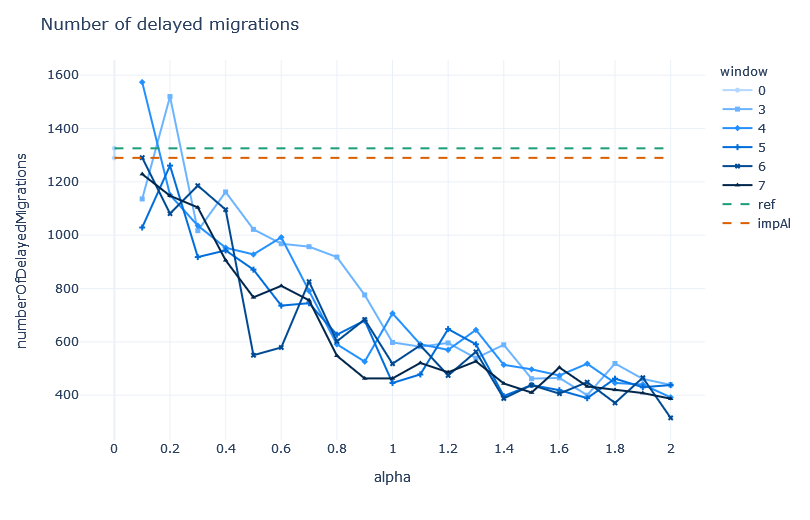

In [27]:
loadExperimentConfigurations()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
customFilter = {
                    #"hostForecastingTechnique": ["fbProphet"]
                }
classify = "hostForecastingTechnique"

copyDf = df.copy()
copyDf.reset_index(inplace=True)
copyDf = getAllowedFilteredDf(copyDf, customFilter)

#copyDf["hostSignalProcessingParams"] = copyDf["hostSignalProcessingParams"].apply(lambda x: 0 if len(x) < 1 else x[0])
#copyDf["vmSignalProcessingParamsAccurate"] = copyDf["vmSignalProcessingParamsAccurate"].apply(lambda x: 0 if len(x) < 1 else x[0])
#copyDf["vmSignalProcessingParamsBasic"] = copyDf["vmSignalProcessingParamsBasic"].apply(lambda x: 0 if len(x) < 1 else x[0])

copyDf["window"] = copyDf["hostSignalProcessingParams"].apply(lambda x: 0 if len(x) < 1 else x[0])
copyDf["alpha"] = copyDf["hostSignalProcessingParams"].apply(lambda x: 0 if len(x) < 1 else x[1])
copyDf["ratioES"] = copyDf["energy+hosts+migrations"] / copyDf["slaOverall"]
copyDf["timeElapsed"] = copyDf["timeElapsed"]/(1000000000*60)

#getExperiment(copyDf, verbose=True)

ref = getAllowedFilteredDf(copyDf, {"hostForecastingTechnique":["last"], "vmForecastingTechniqueAccurate":["last"], "alpha":[0], "window":[0]})

hostForecastingTechnique = "fbProphet"
#knnParam = 4
#copyDf["hspp"] = copyDf["hostSignalProcessingParams"].apply(lambda x: 0 if len(x) < 1 else x[0])

improvementAlone = getAllowedFilteredDf(copyDf, {"hostForecastingTechnique":[hostForecastingTechnique], "hostSignalProcessing":["none"]})
improvementBollinger = getAllowedFilteredDf(copyDf, {"hostForecastingTechnique":[hostForecastingTechnique], "hostSignalProcessing":["bollinger"]})
improvementInterpeaks = getAllowedFilteredDf(copyDf, {"hostForecastingTechnique":[hostForecastingTechnique], "hostSignalProcessing":["interpeaks"]})

dfList = [ref, improvementAlone, improvementInterpeaks]
print("Count:")
for currentDf in dfList:
    print(len(currentDf))
finalDf = pd.concat(dfList)

finalDf['id'] = getConcatColumn(finalDf, ["hostForecastingTechnique", "alpha", "window"])

#showOptions(filteredDf)
metrics = ["totalUsedHosts", "energy", "numberOfMigrations", "slaOverall",
           "numberOfHostShutdowns", "networkPhysicalResults-totalSaturatedData",
           'networkPhysicalResults-totalBWUsed', 'totalNonSatisfiedMips',
           'averagePercentageOfNonSatisfiedByTotalMips',
           'totalUnsatisfiedHosts', 'totalUnsatisfiedVMs',
           'slaTimePerActiveHost', 'totalWastedMIPS', 'medianCPUDispersionOfActiveHosts',
           'sla']
metrics =["timeElapsed", "ratioES", "totalUsedHosts", "numberOfHostShutdowns", "energy", "energy+hosts+migrations", "slaOverall", "sla", "numberOfMigrations", "numberOfDelayedMigrations"]

#filteredDf = getAllExceptFilteredDf(filteredDf, {"hostForecastingTechnique":["last"], "vmForecastingTechniqueAccurate":["last"], "alpha":[0], "window":[0]})


firstParam = "window"
secondParam = "alpha"

refDict = {"ref": getAllowedFilteredDf(ref, {firstParam: [k]}) for k in ref[firstParam].unique().tolist()}
refAlone = {"impAl": getAllowedFilteredDf(improvementAlone, {firstParam: [k]}) for k in ref[firstParam].unique().tolist()}

refDict = {**refDict, **refAlone}

#highlightsList = [{"index":10, "color": "#ff9f33"}, {"index":11, "color": "red"}]
#highlightsList = [{"index":1, "color": "#ff9f33"}]
highlightsList = []

#filteredDf["energy+hosts+migrations"] = -filteredDf["energy+hosts+migrations"]
#filteredDf["slaOverall"] = -filteredDf["slaOverall"]
#showPareto2DBasic(filteredDf, "slaOverall", "energy+hosts+migrations")
#showPareto2DBasic(filteredDf, "energy+hosts+migrations", "slaOverall")

figures = showPlotlySlicedLineSurface(finalDf, metrics, heatmapColumns = [firstParam, secondParam], ref=refDict, comparative=False, highlights=highlightsList, size=(600, 520), dtick=0.2, markerSize=5)

#showPlotlyBarStatistics(finalDf, metrics, "id", hover_data=["index"], color="id", size=(700, 500))

#group = dp.Group(blocks=[dp.Plot(x) for x in figures], columns=1) 
#dp.Report(group).upload(name='paper3_pareto')